In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:


# =========================
# LOAD DATA
# =========================

atl_temp = pd.read_csv("ATL_TEMP_2000_2025_cleaned.csv")
atl_aqi = pd.read_csv("ALL_AQI_2000_2025.csv")
la_full = pd.read_csv("cleaned_air_quality_final.csv")

# =========================
# ATLANTA
# =========================

# Convert dates
atl_temp["DATE"] = pd.to_datetime(atl_temp["DATE"])
atl_aqi["Date"] = pd.to_datetime(atl_aqi["Date"])

# Create month column
atl_temp["YearMonth"] = atl_temp["DATE"].dt.to_period("M")
atl_aqi["YearMonth"] = atl_aqi["Date"].dt.to_period("M")

# Monthly averages
atl_temp_m = atl_temp.groupby("YearMonth")["TAVG"].mean().reset_index()
atl_aqi_m = atl_aqi.groupby("YearMonth")["PM2.5 AQI Value"].mean().reset_index()

# Merge
atl = pd.merge(atl_temp_m, atl_aqi_m, on="YearMonth", how="inner")

# =========================
# LOS ANGELES
# =========================

# Filter for Los Angeles
la = la_full[la_full["City"].str.contains("Los Angeles", case=False, na=False)].copy()

# Convert date
la["Date"] = pd.to_datetime(la["Date"])

# Create month column
la["YearMonth"] = la["Date"].dt.to_period("M")

# Monthly averages
la_m = la.groupby("YearMonth")[["Temp", "AQI"]].mean().reset_index()


C:\Users\sebastian\AppData\Local\Temp\ipykernel_35772\4225392680.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  atl_temp["DATE"] = pd.to_datetime(atl_temp["DATE"])


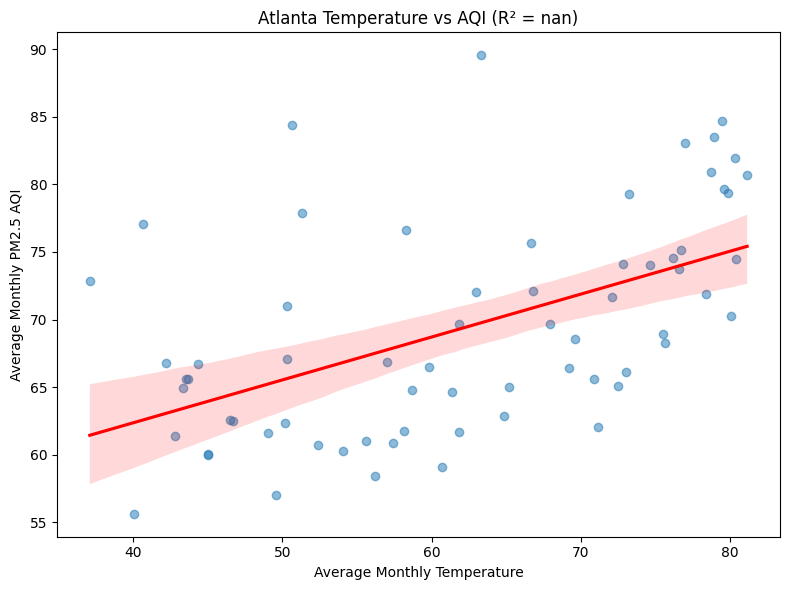

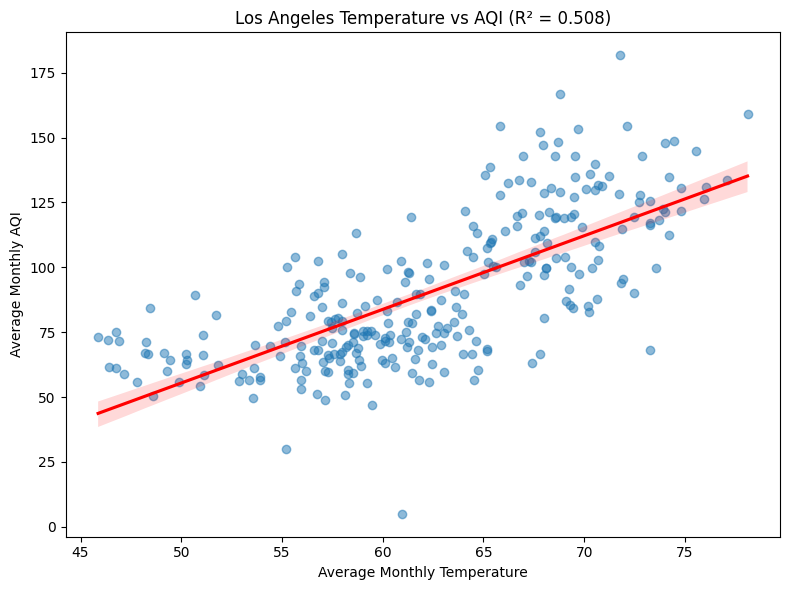

In [15]:

from scipy.stats import linregress

# =========================
# ATLANTA (with regression line)
# =========================

slope, intercept, r_value, p_value, std_err = linregress(atl["TAVG"], atl["PM2.5 AQI Value"])
r_squared_atl = r_value**2

plt.figure(figsize=(8,6))
sns.regplot(x=atl["TAVG"], y=atl["PM2.5 AQI Value"],
            scatter_kws={"alpha":0.5},
            line_kws={"color":"red"})

plt.title(f"Atlanta Temperature vs AQI (R² = {r_squared_atl:.3f})")
plt.xlabel("Average Monthly Temperature")
plt.ylabel("Average Monthly PM2.5 AQI")
plt.tight_layout()
plt.show()


# =========================
# LOS ANGELES (with regression line)
# =========================

slope, intercept, r_value, p_value, std_err = linregress(la_m["Temp"], la_m["AQI"])
r_squared_la = r_value**2

plt.figure(figsize=(8,6))
sns.regplot(x=la_m["Temp"], y=la_m["AQI"],
            scatter_kws={"alpha":0.5},
            line_kws={"color":"red"})

plt.title(f"Los Angeles Temperature vs AQI (R² = {r_squared_la:.3f})")
plt.xlabel("Average Monthly Temperature")
plt.ylabel("Average Monthly AQI")
plt.tight_layout()
plt.show()

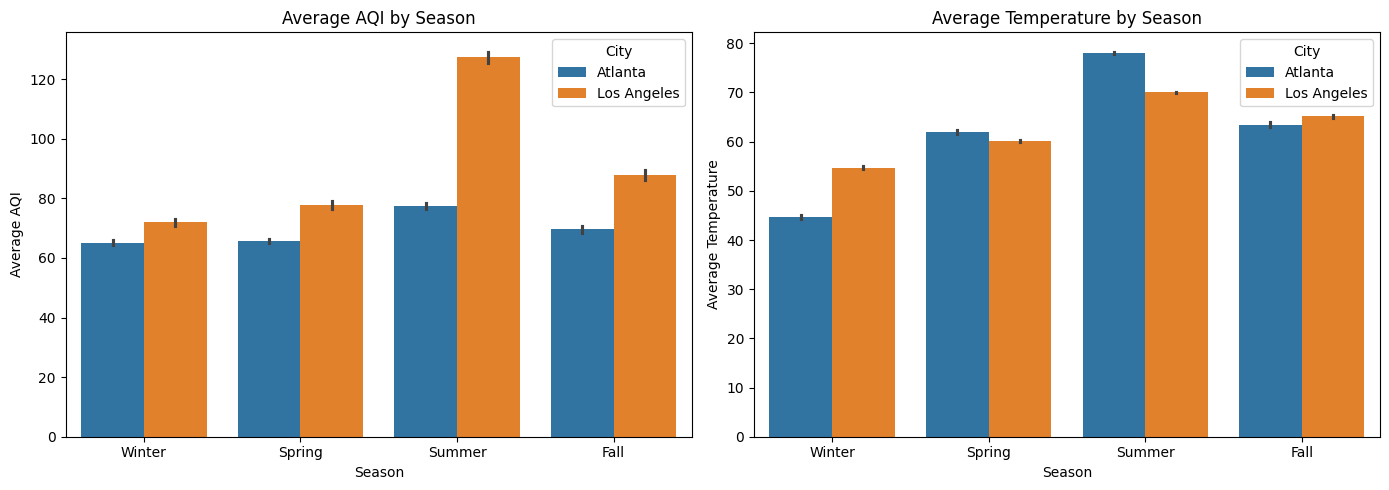

These graphs compare seasonal temperature and AQI patterns across Atlanta and Los Angeles. In general, warmer seasons tend to show higher AQI.


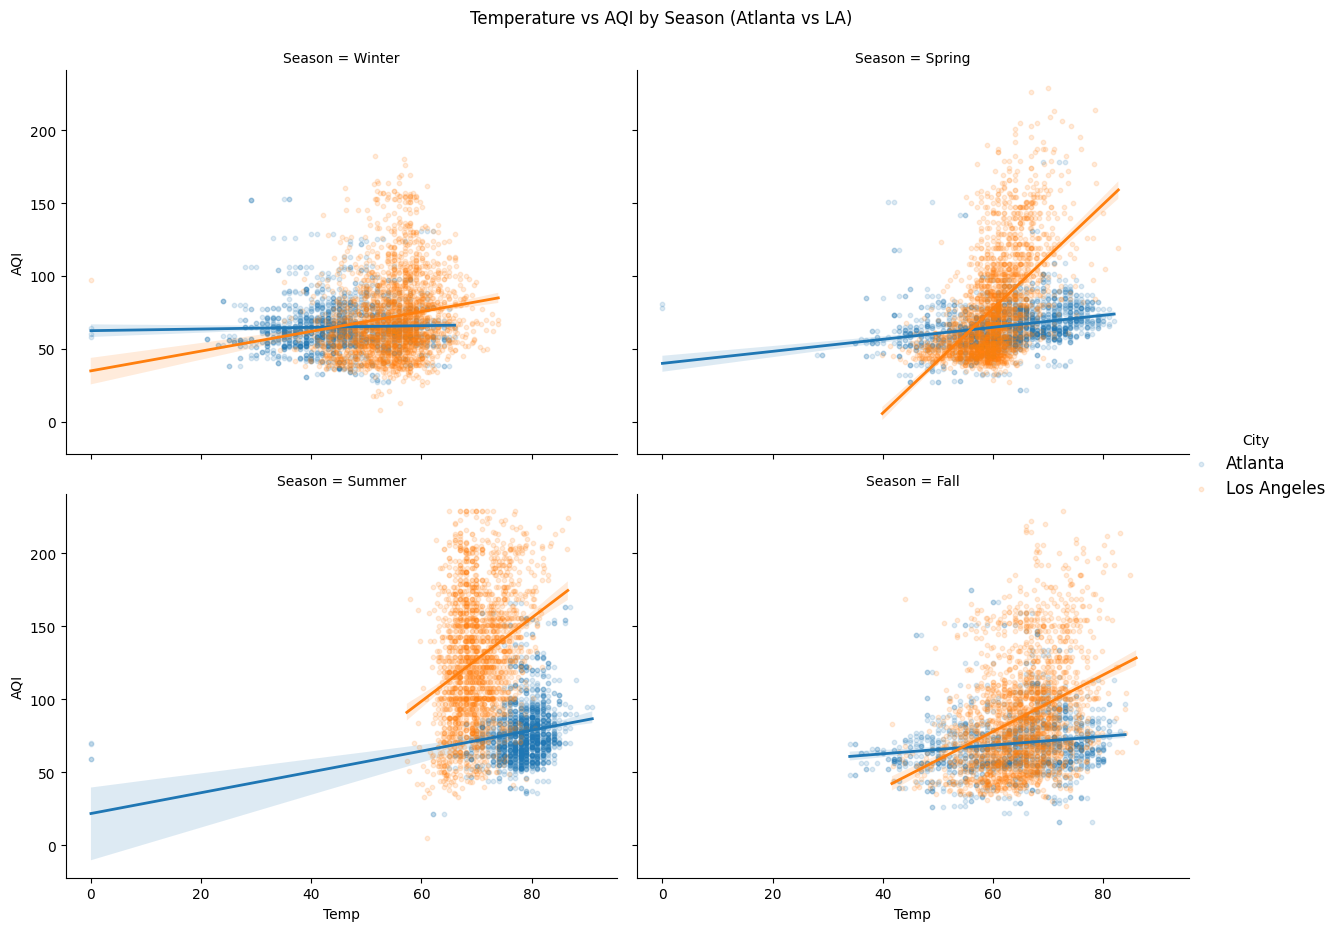

This graph compares the relationship between temperature and AQI across seasons in both cities. It helps show whether warmer conditions are associated with higher AQI.


In [17]:



# rename columns so both cities match
atl_temp = atl_temp.rename(columns={"DATE": "Date", "TAVG": "Temp"})
atl_aqi = atl_aqi.rename(columns={"PM2.5 AQI Value": "AQI"})

# merge Atlanta temp + AQI by date
atl_df = pd.merge(
    atl_temp[["Date", "Temp"]],
    atl_aqi[["Date", "AQI"]],
    on="Date",
    how="inner"
)

atl_df["City"] = "Atlanta"

# =========================
# PREPARE LOS ANGELES DATA
# =========================

la_df = la_full[la_full["City"].str.contains("Los Angeles", case=False, na=False)].copy()
la_df["Date"] = pd.to_datetime(la_df["Date"])

# keep only needed columns
la_df = la_df[["Date", "Temp", "AQI"]]
la_df["City"] = "Los Angeles"

# =========================
# COMBINE BOTH CITIES
# =========================

df = pd.concat([atl_df, la_df], ignore_index=True)

# drop missing values just in case
df = df.dropna(subset=["Date", "Temp", "AQI"])

# =========================
# CREATE SEASON COLUMN
# =========================

def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

df["Season"] = df["Date"].dt.month.apply(get_season)

season_order = ["Winter", "Spring", "Summer", "Fall"]

# =========================
# GRAPH 1:
# AVERAGE AQI BY SEASON &
# AVERAGE TEMPERATURE BY SEASON
# =========================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df, x="Season", y="AQI", hue="City", order=season_order, ax=axes[0])
axes[0].set_title("Average AQI by Season")
axes[0].set_xlabel("Season")
axes[0].set_ylabel("Average AQI")

sns.barplot(data=df, x="Season", y="Temp", hue="City", order=season_order, ax=axes[1])
axes[1].set_title("Average Temperature by Season")
axes[1].set_xlabel("Season")
axes[1].set_ylabel("Average Temperature")

plt.tight_layout()
plt.show()

print("These graphs compare seasonal temperature and AQI patterns across Atlanta and Los Angeles. In general, warmer seasons tend to show higher AQI.")

# =========================
# GRAPH 2:
# TEMPERATURE VS AQI BY SEASON
# =========================

g = sns.lmplot(
    data=df,
    x="Temp",
    y="AQI",
    hue="City",
    col="Season",
    col_order=season_order,
    col_wrap=2,
    scatter_kws={"alpha": 0.15, "s": 10},
    line_kws={"linewidth": 2},
    height=4.5,
    aspect=1.35
)

g._legend.set_title("City")
for text in g._legend.texts:
    text.set_fontsize(12)

plt.suptitle("Temperature vs AQI by Season (Atlanta vs LA)", y=1.03)
plt.show()

print("This graph compares the relationship between temperature and AQI across seasons in both cities. It helps show whether warmer conditions are associated with higher AQI.")